# Project Name - Titanic Survival Predication

In [69]:
# import library
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [70]:
# load the dataset
test = pd.read_csv("D:/Project/Titanic-Prediction/data/test.csv")
train = pd.read_csv("D:/Project/Titanic-Prediction/data/train.csv")

In [71]:
# first 5 data
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [72]:
# present columns
train.columns 

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [73]:
# shape of data
row, columns = train.shape
print(f" Row:{row}\n Columns:{columns}")

 Row:891
 Columns:12


In [74]:
# info 
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [75]:
# check null values
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

### Observation
- As we can see out of 891 [Age, Cabin, Embarked] misses the data 
- Cabin misses out 687 out of 891
- Embarked misses with 2 data 

In [76]:
# Duplicate values
train.duplicated().sum(0)

np.int64(0)

In [77]:
# Detaile info of data
train['Age'].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

# EDA

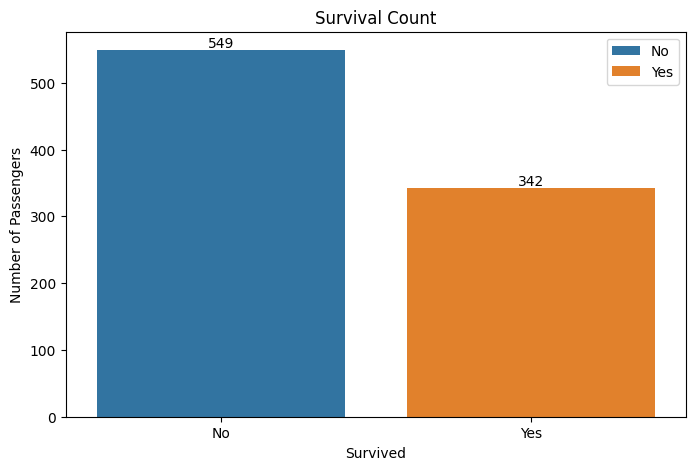

In [90]:
# Survival Count

plt.figure(figsize=(8,5))
ax = sns.countplot(data=train,x=train['Survived'],hue='Survived')

plt.title('Survival Count')
plt.xticks(ticks=[0, 1], labels=["No", "Yes"])
plt.ylabel('Number of Passengers')

for container in ax.containers:
    ax.bar_label(container)

plt.legend(
    labels = ["No","Yes"]
    )
plt.show()

### Observation
- In survival count, we can see "Not survived" passengers are more as compare to survived.   
- Number of passengers that didn't survived is 549.

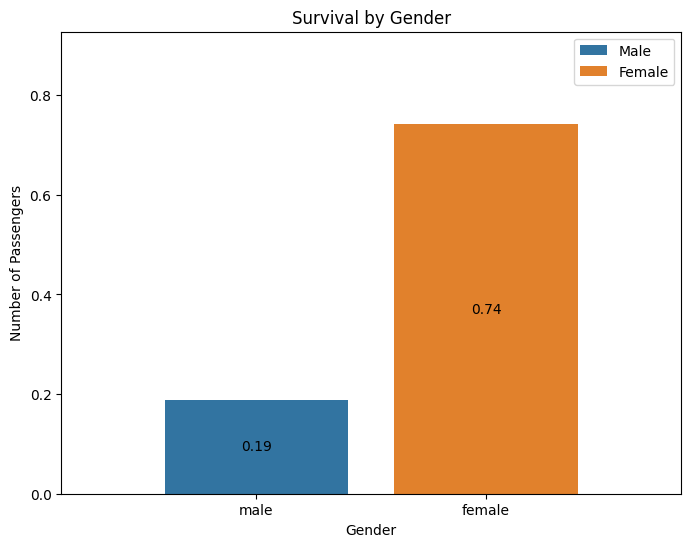

In [129]:
# Survival by gender

plt.figure(figsize=(8,6))
ax = sns.barplot(data=train,x=train['Sex'],y=train['Survived'],hue='Sex',errorbar=None)
ax.bar_label(ax.containers[0],fmt="%.2f",label_type='center')
ax.bar_label(ax.containers[1],fmt="%.2f",label_type='center')
plt.legend(
    labels = ['Male','Female']
)
ax.margins(0.25)
plt.title('Survival by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Passengers')
plt.show()

### Observation
- As we see, females have survived the most, on ratio of male.
- Survival rate of females is 0.74% and male is 0.19%.

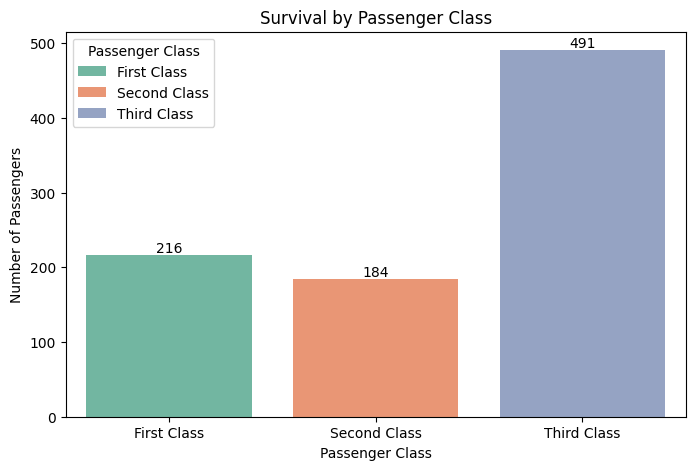

In [133]:
# Survival by Passenger class

plt.figure(figsize=(8,5))

ax = sns.countplot(x=train['Pclass'],hue=train['Pclass'],palette='Set2')

for container in ax.containers:
    ax.bar_label(container,label_type='edge')

plt.title('Survival by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Number of Passengers')
plt.xticks(ticks=[0,1,2],labels=['First Class','Second Class','Third Class'])
plt.legend(
    title = 'Passenger Class',
    labels = ['First Class','Second Class','Third Class']
)
plt.show()